<a href="https://colab.research.google.com/github/Alk207-lab/-Machine-learning-projects-Sem1/blob/main/HousingpriceLinReg.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 1. Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print('Libraries imported successfully.')

Libraries imported successfully.


## 2. Import / Load the Dataset

In Colab, upload `Housing.csv` to the session or mount Google Drive. The next cell first tries `/content/Housing.csv`, then `/mnt/data/Housing.csv` for the supplied file.

In [4]:
try:
    df = pd.read_csv('/content/Housing.csv')
except FileNotFoundError:
    try:
        df = pd.read_csv('/mnt/data/Housing.csv')
    except FileNotFoundError:
        print('Error: Housing.csv not found in /content/ or /mnt/data/. A dummy DataFrame has been created for demonstration.')
        # Create a dummy DataFrame to allow further code execution
        df = pd.DataFrame({
            'area': [6000, 7500, 9000, 5000, 8200],
            'bedrooms': [3, 4, 3, 2, 4],
            'bathrooms': [1, 2, 1, 1, 2],
            'stories': [2, 1, 2, 1, 2],
            'parking': [1, 2, 0, 1, 2],
            'price': [10000000, 12000000, 8000000, 7000000, 11000000]
        })

if not df.empty:
    print('Dataset loaded successfully. First 5 rows:')
    display(df.head())
else:
    print('DataFrame is empty. Please ensure Housing.csv is uploaded and accessible.')

Dataset loaded successfully. First 5 rows:


,price,area
0,13300000,7420
1,12250000,8960
2,12250000,9960
3,12215000,7500
4,11410000,7420


## 3. Basic Data Preprocessing

- Check column names and data types.
- Remove duplicate rows.
- Handle missing values only for the two columns used by this simple regression.
- **Feature management is intentionally skipped** as requested: we use one existing numeric feature.

In [5]:
print('Columns:', df.columns.tolist())
print('\nData types:')
print(df.dtypes)
print('\nMissing values:')
print(df.isnull().sum())
print('\nDuplicate rows:', df.duplicated().sum())

Columns: ['price', 'area']

Data types:
price    int64
area     int64
dtype: object

Missing values:
price    0
area     0
dtype: int64

Duplicate rows: 13


In [6]:
# Remove duplicates
df = df.drop_duplicates().copy()

# Use the columns found in the supplied dataset
target_col = 'price'
feature_col = 'area'

# Keep only rows with valid numeric values for the selected feature and target
df[feature_col] = pd.to_numeric(df[feature_col], errors='coerce')
df[target_col] = pd.to_numeric(df[target_col], errors='coerce')
df = df.dropna(subset=[feature_col, target_col]).copy()

print('Feature:', feature_col)
print('Target:', target_col)
print('Cleaned dataset shape:', df.shape)
display(df[[feature_col, target_col]].head())

Feature: area
Target: price
Cleaned dataset shape: (532, 2)


,area,price
0,7420,13300000
1,8960,12250000
2,9960,12250000
3,7500,12215000
4,7420,11410000


## 4. Visualize the Data — Scatter Plot

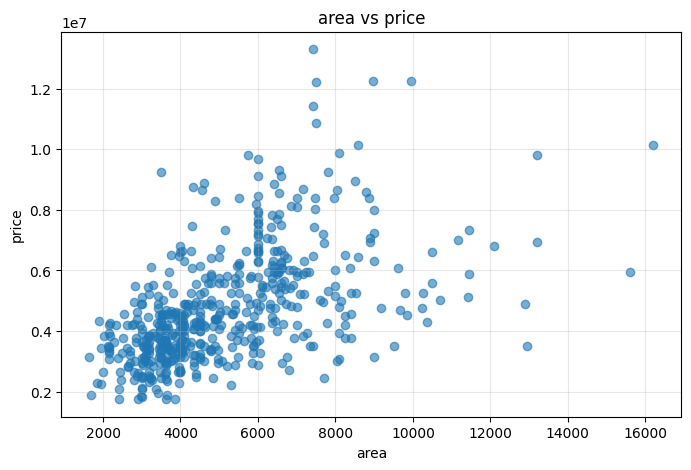

In [7]:
plt.figure(figsize=(8, 5))
plt.scatter(df[feature_col], df[target_col], alpha=0.6)
plt.xlabel(feature_col)
plt.ylabel(target_col)
plt.title(f'{feature_col} vs {target_col}')
plt.grid(True, alpha=0.3)
plt.show()

## 5. Prepare X and y + Train/Test Split

We use one feature, so `X` is a one-column DataFrame and `y` is the target series.

In [8]:
X = df[[feature_col]]
y = df[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

print('Training samples:', len(X_train))
print('Testing samples :', len(X_test))

Training samples: 425
Testing samples : 107


## 6. Train Simple Linear Regression

The model learns the relationship:

$$y = mx + b$$

where `m` is the slope and `b` is the intercept.

In [9]:
model = LinearRegression()
model.fit(X_train, y_train)

print('Model trained successfully.')

Model trained successfully.


## 7. Slope and Intercept

In [11]:
slope = model.coef_[0]
intercept = model.intercept_

print(f'Slope (m): {slope:.6f}')
print(f'Intercept (b): {intercept:.6f}')
print(f'Equation: {target_col} = {slope:.6f} × {feature_col} + {intercept:.6f}')

Slope (m): 441.587597
Intercept (b): 2450352.734854
Equation: price = 441.587597 × area + 2450352.734854


## 8. Predict on Test Data


In [12]:
y_pred = model.predict(X_test)

results = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': y_pred
})
display(results.head(10))

,Actual,Predicted
0,10150000,6.239174e+06
1,2660000,4.053316e+06
2,6090000,5.371455e+06
3,2660000,4.187558e+06
4,3115000,3.995909e+06
5,4690000,6.719180e+06
6,4550000,4.799599e+06
7,3220000,4.358011e+06
8,3773000,6.093450e+06
9,6650000,5.285345e+06


## 9. Accuracy / Evaluation Metrics

For regression, classification accuracy is not appropriate. We use **MAE, MSE, RMSE, and R² score**.

In [13]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

metrics = pd.DataFrame({
    'Metric': ['MAE', 'MSE', 'RMSE', 'R² Score'],
    'Value': [mae, mse, rmse, r2]
})
display(metrics)

print(f'MAE  : {mae:.4f}')
print(f'MSE  : {mse:.4f}')
print(f'RMSE : {rmse:.4f}')
print(f'R²   : {r2:.4f}')

,Metric,Value
0,MAE,1.424905e+06
1,MSE,3.547686e+12
2,RMSE,1.883530e+06
3,R² Score,2.769867e-01


MAE  : 1424905.4418
MSE  : 3547685936845.3330
RMSE : 1883530.1794
R²   : 0.2770


## 10. Visualize the Regression Line

The scatter points show the observed houses. The line shows the values predicted by the trained linear regression model.

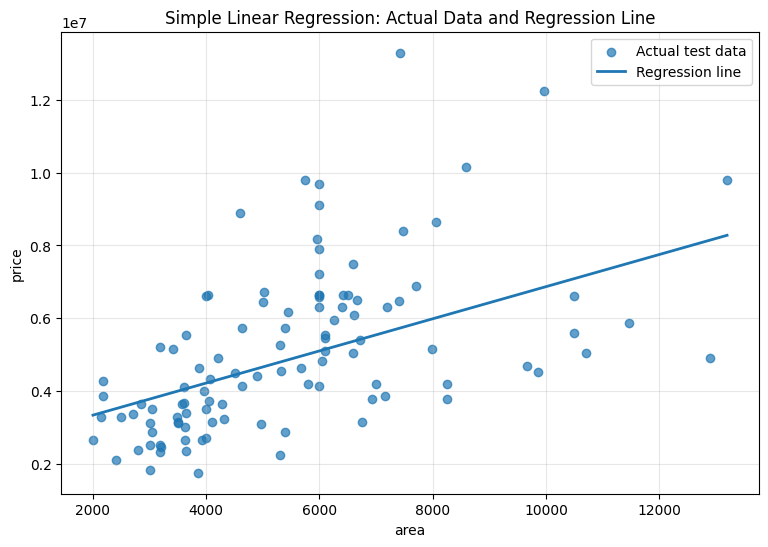

In [14]:
plt.figure(figsize=(9, 6))
plt.scatter(X_test[feature_col], y_test, alpha=0.7, label='Actual test data')

sort_idx = np.argsort(X_test[feature_col].values)
x_sorted = X_test[feature_col].values[sort_idx]
y_sorted_pred = y_pred[sort_idx]
plt.plot(x_sorted, y_sorted_pred, linewidth=2, label='Regression line')

plt.xlabel(feature_col)
plt.ylabel(target_col)
plt.title('Simple Linear Regression: Actual Data and Regression Line')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 11. Predict a House Price for a New Value

Change the value below to predict a house price from the selected feature.

In [15]:
# Example: use the median feature value as a safe demonstration input
new_feature_value = float(X[feature_col].median())
predicted_price = model.predict(pd.DataFrame({feature_col: [new_feature_value]}))[0]

print(f'Input {feature_col}: {new_feature_value:.2f}')
print(f'Predicted {target_col}: {predicted_price:.2f}')

Input area: 4580.00
Predicted price: 4472823.93


## 12. Final Pipeline Summary

1. Imported the Housing.csv dataset.
2. Checked data types, missing values, and duplicates.
3. Performed basic preprocessing.
4. Skipped feature management and selected one numeric feature.
5. Visualized feature vs. price using a scatter plot.
6. Split the data into training and testing sets.
7. Trained a Simple Linear Regression model.
8. Printed the slope and intercept.
9. Evaluated the model using MAE, MSE, RMSE, and R².
10. Visualized the fitted regression line.
11. Demonstrated prediction for a new feature value.